In [1]:
## Code written by Ben Young & Annika Christiansen, University of Oregon
import random
import itertools
from itertools import pairwise
import matplotlib.pyplot as plt

def to_perm(word,n):
    perm = list(range(1,n+1))
    k = len(perm)
    for i in word:
        perm[i-1],perm[i] = perm[i],perm[i-1]
        
    return(perm)

def inv(perm):
    count = []
    for i in range(len(perm)):
        for j in range(i+1,len(perm)):
            if perm[i] > perm[j]:
                count.append((i,j))
    return(len(count))

def reduced(word):
    if len(word) == inv(to_perm(word,max(word)+1)):
        return(True)
    else:
        return(False)



class Crossing:
    def __init__(self, what_row, word = None, col = None):
        if type(what_row) == Crossing:
            self.row = what_row.row
        else:
            self.row = what_row
        self.word = word
        self.col = col

    def __str__(self):
        if self.row == 0:
            return "0"
        else:
            return "{}".format(self.row)
            
    def __repr__(self):
        return self.__str__()

    def __eq__(self, other):
        return self.row == other.row

    def push(self, which_row):
        if which_row > 0:
            assert which_row == self.row, "the crossing {} is not in positive row {}".format(self, which_row)
            self.row -= 1
        return self.row

    def to_magnet_pair(self):
        return [self.row]

In [2]:
from itertools import pairwise

memoize_unimodal_check = {}
class Word:
    def __init__(self, crossing_row_list, n=None):
        self.length = len(crossing_row_list)
        self.crossings = []
        for (col, row) in enumerate(crossing_row_list):
            self.crossings.append(Crossing(row, self, col))
        self.old_style_word = crossing_row_list
        if n == None:
            self.n = max(self.old_style_word)+1
        else:
            self.n=n
        self.compute_wires()
                
    def __str__(self):
        return "Word {}".format(self.crossings)

    def __repr__(self):
        return self.__str__()

    def __getitem__(self, i):
        return self.crossings[i]

    def __len__(self):
        return self.length
    
    def compute_old_style_word(self):
        self.old_style_word = [c.row for c in self.crossings]

    def tau(self,strings,i,m):
    # string a tuple, loc a list
        perm = list(strings)
        k = len(perm)
        perm[i-1],perm[i] = perm[i],perm[i-1]
        return tuple(perm)

    def perm(self):
        return sgnperm(self.old_style_word, self.n)

    def reduced(self):
        return reduced(self.old_style_word)

    def nearly_reduced(self, i):
        my_crossings = self.old_style_word
        shorter_crossings = my_crossings[:i] + my_crossings[i+1:]
        w = Word(shorter_crossings)
        return w.reduced()

    def draw(self, ax):
        self._draw_word(self.old_style_word, ax)
        
    def _draw_word(self,word,ax):
        start = -0.25
        k = len(word)
        n = max(word)+1
    
        dic = {}
        # initialize plot, label the starting points
        for i in range(1,n+1):
            ax.text(start,i-1,str(i))
            dic[i] = [i-1]
     
        y = tuple(range(1,n+1))
    
        for i in range(len(word)):
            # apply the simple reflection w_i
            new = self.tau(y,word[i],self.n)
            for j in range(1,n+1):
                dic[j].append(new.index(j))
            y = new
    
        x = tuple(range(0,k+1))
        for i in range(1,n+1):
            ax.plot(x,tuple(dic[i]))
    
        # label the ending points
        for i in range(len(y)):
            ax.text(k+0.5+start,i,str(y[i]))

        # draw
        ax.axis("off")
        ax.set_aspect(1)
        plt.show()
        return ax

    def compute_wires(self):
        points = list(range(1, self.n+1))
        pi = {u:u for u in points}
        pi_inv = {u:u for u in points}
        wires = {i:[i] for i in points}
        wires_by_height = {i:[i] for i in points}
        for cross in self.crossings:
            r = cross.row
            swaps=[(r,r+1)]
            for (r,s) in swaps: 
                i = pi_inv[r]
                j = pi_inv[s]
                (pi[i], pi[j]) = (pi[j], pi[i])
                (pi_inv[s], pi_inv[r]) = (pi_inv[r], pi_inv[s])
            for i,w in wires.items():
                w.append(pi[i])
            for i,w in wires_by_height.items():
                w.append(pi_inv[i])
        self.wires = wires
        self.wires_by_height = wires_by_height

    def push(self, row, col):
        self.crossings[col].push(row)
        new_crossings = []
        if self.crossings[col].row == 0:
            for i in range(0,len(self.crossings)):
                self.crossings[i].row += 1
            self.compute_old_style_word()
            self.n = max(self.old_style_word)+1
            self.compute_wires()
            return row
        else:
            self.compute_old_style_word()
            self.n = max(self.old_style_word)+1
            self.compute_wires()
            return row-1

    def _crossing_from_wire_heights(self,i,j):
        if i > j:
            (i,j) = (j,i) # now i <= j
        if i >= 1 and j == i+1:
            return i
        else:
            raise Exception("You've asked me what the height of the {} crossing is, and that makes no sense".format(i,j))

    def _wire_heights_from_crossing(self, row):
        return (row, row+1)
    
    def wire_crossings(self, wire_1, wire_2):
        if wire_1 not in self.wires or wire_2 not in self.wires:
            return [] # wires don't cross
        crossings = []
        for col, ((old_h1, old_h2), (h1, h2)) in enumerate(pairwise(zip(self.wires[wire_1], self.wires[wire_2]))):
            if old_h1 == h2 and old_h2 == h1:
                row = self._crossing_from_wire_heights(h1, h2)
                crossings.append((row, col))
        return crossings

    def wires_from_crossing(self, row, col):
        i,j = self._wire_heights_from_crossing(row)
        wire_1 = self.wires_by_height[i][col]
        wire_2 = self.wires_by_height[j][col]
        return min(wire_1, wire_2), max(wire_1, wire_2)

    def bump_crossing(self, start_row, start_col):
        assert self.reduced(), "Not reduced"
        assert self.nearly_reduced(start_col), "Not nearly reduced at {}".format(start_col+1)
        row = start_row
        col = start_col
        word_path = [list(self.old_style_word)]
        while True:
            print(self)
            row = self.push(row, col)
            word_path.append(list(self.old_style_word))
            
            w1, w2 = self.wires_from_crossing(row, col)
            defects = self.wire_crossings(w1, w2)
            fig, ax = plt.subplots()
            self.draw(ax)
            if len(defects) == 1:
                print(self, "done")
                return word_path
            else:
                assert len(defects) == 2, "something is horribly wrong"
                for cross in defects:
                    if cross != (row, col):
                        (row, col) = cross
                        break

    def bump(self, wire_1, wire_2):
        crossings = self.wire_crossings(wire_1, wire_2)
        #print(f"here are the possible crossings {crossings}")
        assert len(crossings) != 0, "those wires don't cross"
        assert self.reduced(), "not reduced"
        row, col = crossings[0]
        return self.bump_crossing(row, col)

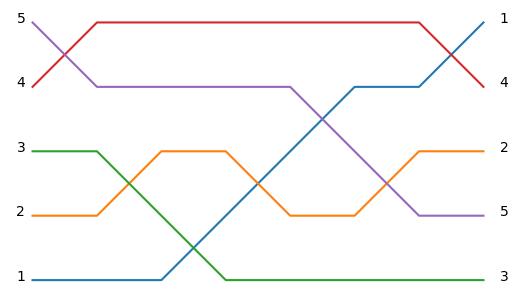

AssertionError: Not nearly reduced at 3

In [3]:
w = Word([4,2,1,2,3,2,4])
fig, ax = plt.subplots()
w.draw(ax)
w.bump(1,3)

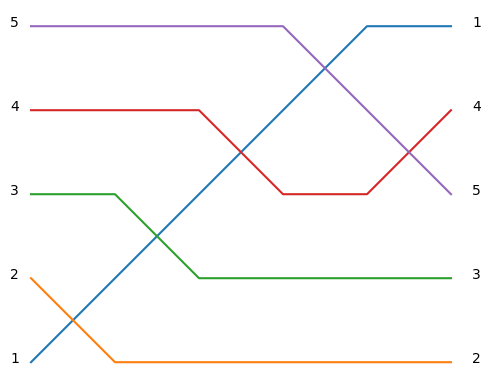

Word [1, 2, 3, 4, 3]


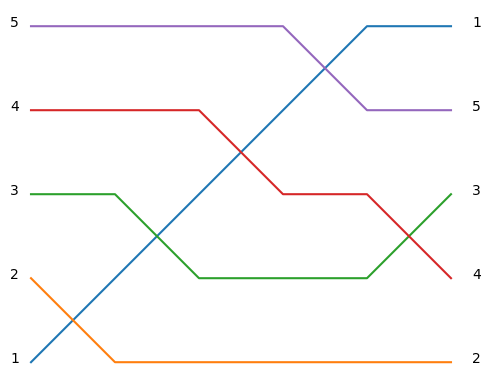

Word [1, 2, 3, 4, 2] done
[[1, 2, 3, 4, 3], [1, 2, 3, 4, 2]]
Word [1, 2, 3, 4, 2]


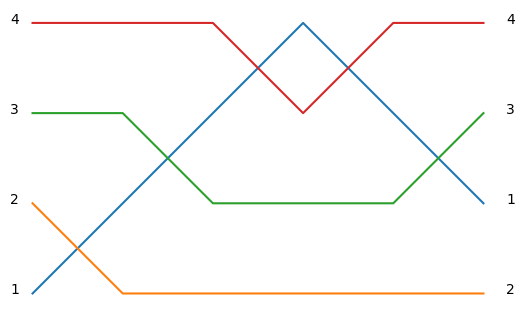

Word [1, 2, 3, 3, 2]


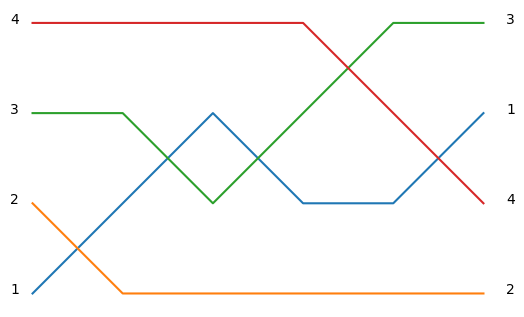

Word [1, 2, 2, 3, 2]


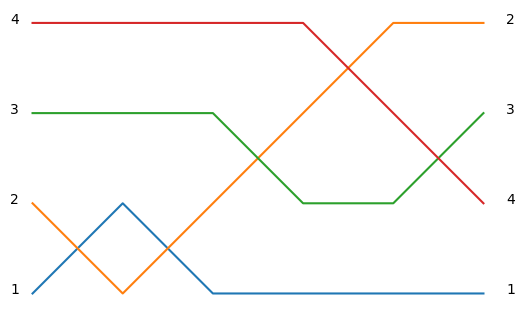

Word [1, 1, 2, 3, 2]


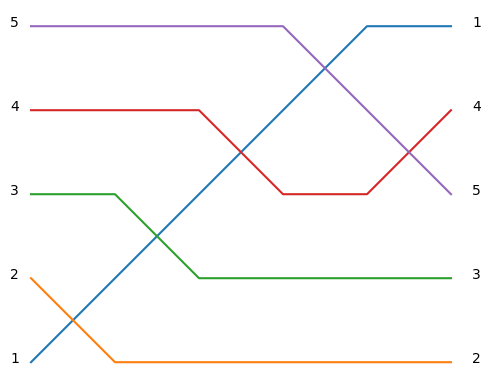

Word [1, 2, 3, 4, 3] done
[[1, 2, 3, 4, 2], [1, 2, 3, 3, 2], [1, 2, 2, 3, 2], [1, 1, 2, 3, 2], [1, 2, 3, 4, 3]]


In [ ]:
fig, ax = plt.subplots()
w = Word([1,2,3,4,3])
w.draw(ax)

## bump the last (fifth) crossing: output should be the reduced word 12342 via the push sequence/path 12343-12342
x = w.bump(4,5)
print(x)
## bump the fourth crossing: output should be the reduced word 12343 via the push sequence/path 12342-12332-12232-11232-12343
y = w.bump(1,5)
print(y)

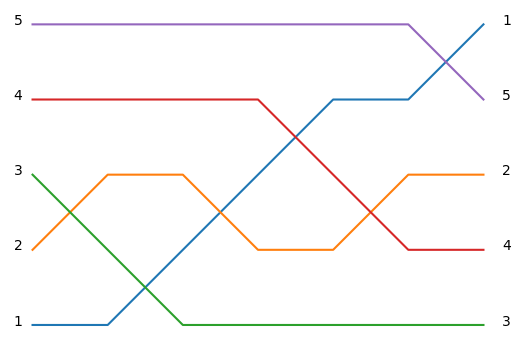

Word [2, 1, 2, 3, 2, 4]


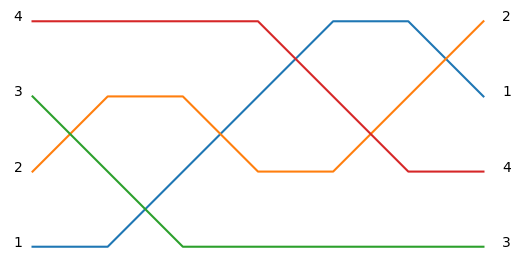

Word [2, 1, 2, 3, 2, 3]


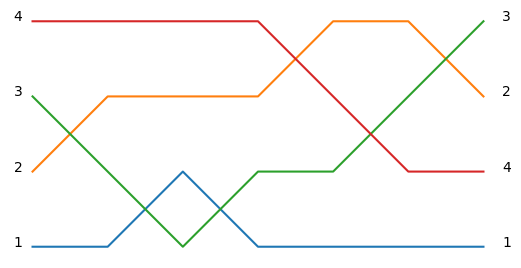

Word [2, 1, 1, 3, 2, 3]


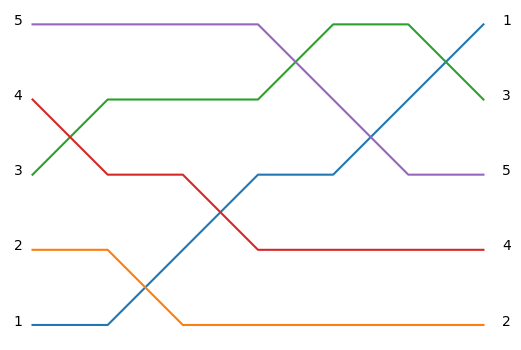

Word [3, 1, 2, 4, 3, 4] done


[[2, 1, 2, 3, 2, 4],
 [2, 1, 2, 3, 2, 3],
 [2, 1, 1, 3, 2, 3],
 [3, 1, 2, 4, 3, 4]]

In [ ]:
w = Word([2,1,2,3,2,4])
fig, ax = plt.subplots()
w.draw(ax)

## bump the last (fifth) crossing: output should be the reduced word 312434 via the push sequence/path 212324-212323-211323-312434
w.bump(1,5)

In [ ]:
## Here's the bumping sequence tableaux:
print(RSK([2,1,2,3,2,4],insertion = RSK.rules.EG))
print(RSK([2,1,2,3,2,3],insertion=RSK.rules.Hecke))
print(RSK([2,1,1,3,2,3],insertion=RSK.rules.Hecke))
print(RSK([3,1,2,4,3,4],insertion = RSK.rules.EG))

[[[1, 2, 3, 4], [2, 3]], [[1, 3, 4, 6], [2, 5]]]
[[[1, 2, 3], [2, 3]], [[(1,), (3,), (4, 6)], [(2,), (5,)]]]
[[[1, 2, 3], [2, 3]], [[(1,), (4,), (6,)], [(2, 3), (5,)]]]
[[[1, 2, 3, 4], [3, 4]], [[1, 3, 4, 6], [2, 5]]]


In [ ]:
##Check that EG agrees with Hecke insertion for reduced word

EG = RSK([2,1,2,3,2,4],insertion = RSK.rules.EG)
Hecke = RSK([2,1,2,3,2,4],insertion = RSK.rules.Hecke)
print(EG)
print(Hecke)

print(EG[0] == Hecke[0])


EG = RSK([3,1,2,4,3,4],insertion = RSK.rules.EG)
Hecke = RSK([3,1,2,4,3,4],insertion = RSK.rules.Hecke)
print(EG)
print(Hecke)

print(EG[0] == Hecke[0])

[[[1, 2, 3, 4], [2, 3]], [[1, 3, 4, 6], [2, 5]]]
[[[1, 2, 3, 4], [2, 3]], [[(1,), (3,), (4,), (6,)], [(2,), (5,)]]]
True
[[[1, 2, 3, 4], [3, 4]], [[1, 3, 4, 6], [2, 5]]]
[[[1, 2, 3, 4], [3, 4]], [[(1,), (3,), (4,), (6,)], [(2,), (5,)]]]
True
